# IoT-23 Dataset

In [ ]:
from pathlib import Path
from urllib.parse import urljoin
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm
from bs4 import BeautifulSoup
from IPython.display import display

try:
    from google.colab import drive
except ImportError:
    drive = None

BASE_URL = "https://mcfp.felk.cvut.cz/publicDatasets/IoT-23-Dataset-v2/"
DRIVE_DIR = Path("/content/drive/MyDrive/flow_guard/iot23_data")

if drive is not None:
    drive.mount("/content/drive", force_remount=False)
    OUT_DIR = DRIVE_DIR
else:
    OUT_DIR = Path("iot23_data")

OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
ROW_LIMITS = {
    "CTU-Honeypot-Capture-7-1": 90000,
    "CTU-IoT-Malware-Capture-1-1": 40000,
}

CAPTURES = {
    "benign": [
        "CTU-Honeypot-Capture-4-1",
        "CTU-Honeypot-Capture-5-1",
        "CTU-Honeypot-Capture-7-1",
        "CTU-Honeypot-Capture-7-2",
        "CTU-Honeypot-Capture-7-3",
        "CTU-Honeypot-Capture-7-4",
        "CTU-Honeypot-Capture-7-5",
        "CTU-Honeypot-Capture-7-6",
    ],
    "malicious": [
        "CTU-IoT-Malware-Capture-1-1",
        "CTU-IoT-Malware-Capture-20-1",
        "CTU-IoT-Malware-Capture-42-1",
        "CTU-IoT-Malware-Capture-8-1",
        "CTU-IoT-Malware-Capture-34-1",
        "CTU-IoT-Malware-Capture-3-1",
    ],
}


Mounted at /content/drive


In [ ]:
splitter = re.compile(r"\t| {2,}")


def split_zeek(text):
    return [part for part in splitter.split(text.rstrip("\n")) if part]


def get_conn_log_url(capture):
    page = requests.get(urljoin(BASE_URL, f"{capture}/"), timeout=60)
    page.raise_for_status()
    soup = BeautifulSoup(page.text, "html.parser")

    for a in soup.select("a[href$='.labeled']"):
        href = a.get("href", "")
        if "zeek-conn" in href:
            return urljoin(page.url, href)

    raise FileNotFoundError(capture)


def download(url, dst):
    if dst.exists():
        return dst

    response = requests.get(url, stream=True, timeout=300)
    response.raise_for_status()
    total = int(response.headers.get("content-length", 0))

    with open(dst, "wb") as f, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=dst.name,
        leave=False,
    ) as bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if not chunk:
                continue

            f.write(chunk)
            bar.update(len(chunk))

    return dst


In [ ]:
def read_conn_log(path, capture, default_label, max_rows=None):
    fields = None
    rows = []

    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            if line.startswith("#fields"):
                fields = split_zeek(line)[1:]
                continue

            if not line.strip() or line.startswith("#"):
                continue

            parts = split_zeek(line)
            if len(parts) != len(fields):
                continue

            rows.append(parts)

            if max_rows and len(rows) >= max_rows:
                break

    df = pd.DataFrame(rows, columns=fields)

    if "label" not in df.columns:
        df["label"] = default_label

    if "detailed-label" not in df.columns:
        df["detailed-label"] = df["label"]

    df["capture"] = capture
    df["target"] = np.where(df["label"].str.lower().eq("benign"), "benign", "malicious")
    return df


In [ ]:
frames = []
capture_rows = []
capture_list = [
    (default_label, capture)
    for default_label, capture_names in CAPTURES.items()
    for capture in capture_names
]

for default_label, capture in tqdm(capture_list, desc="Loading captures"):
    
    url = get_conn_log_url(capture)
    path = download(url, OUT_DIR / url.split("/")[-1])
    df = read_conn_log(path, capture, default_label, ROW_LIMITS.get(capture))

    frames.append(df)
    capture_rows.append(
        {
            "capture": capture,
            "file": path.name,
            "size_mb": round(path.stat().st_size / 1_048_576, 2),
            "rows": len(df),
            "benign_rows": int((df["target"] == "benign").sum()),
            "malicious_rows": int((df["target"] == "malicious").sum()),
        }
    )

raw_df = pd.concat(frames, ignore_index=True)
capture_summary = pd.DataFrame(capture_rows).sort_values("capture").reset_index(drop=True)

display(capture_summary)
raw_df.head()


Loading captures:   0%|          | 0/14 [00:00<?, ?it/s]

,capture,file,size_mb,rows,benign_rows,malicious_rows
0,CTU-Honeypot-Capture-4-1,2018-10-25-14-06-32-192.168.1.132-zeek-conn.lo...,0.06,452,452,0
1,CTU-Honeypot-Capture-5-1,2018-09-21-11-40-22-192.168.2.3-zeek-conn-log....,0.17,1374,1374,0
2,CTU-Honeypot-Capture-7-1,2019-07-03-15-15-47-192.168.1.158-zeek-conn-lo...,1222.38,90000,90000,0
3,CTU-Honeypot-Capture-7-2,2019-07-03-16-41-09-192.168.1.158-zeek-conn-lo...,0.01,52,52,0
4,CTU-Honeypot-Capture-7-3,2019-07-04-16-41-10-192.168.1.158-zeek-conn-lo...,0.00,26,26,0
5,CTU-Honeypot-Capture-7-4,2019-07-05-16-41-14-192.168.1.158-zeek-conn-lo...,0.01,49,49,0
6,CTU-Honeypot-Capture-7-5,2019-07-06-16-41-17-192.168.1.158-zeek-conn-lo...,0.01,53,53,0
7,CTU-Honeypot-Capture-7-6,2019-07-07-16-41-19-192.168.1.158-zeek-conn-lo...,0.01,52,52,0
8,CTU-IoT-Malware-Capture-1-1,2018-05-09-17-30-31-192.168.100.103-zeek-conn-...,137.59,40000,17749,22251
9,CTU-IoT-Malware-Capture-20-1,2018-10-02-13-12-30-192.168.100.103-zeek-conn-...,0.40,3209,3193,16


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed-label,capture,target,detailed_label
0,1540469302.538640,CGm6jB4dXK71ZDWUDh,192.168.1.132,58687,216.239.35.4,123,udp,-,0.114184,48,...,1,76,1,76,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
1,1540469197.400159,CnaDAG3n5r8eiG4su2,192.168.1.132,1900,239.255.255.250,1900,udp,-,160.367579,7536,...,24,8208,0,0,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
2,1540469385.734089,CUrxU238nt0m6yTgKf,192.168.1.132,32893,216.239.35.8,123,udp,-,0.016986,48,...,1,76,1,76,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
3,1540469831.302625,CGQf8t1kjdxB5PHXL4,192.168.1.132,53395,2.16.60.82,443,tcp,-,0.003497,0,...,5,212,3,144,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN
4,1540469831.265405,CUo9DH2QDnCaBIGjkg,192.168.1.132,52801,192.168.1.1,53,udp,dns,0.036724,34,...,1,62,1,339,-,benign,-,CTU-Honeypot-Capture-4-1,benign,NaN


In [ ]:
id_cols = {
    "label", "detailed-label", "detailed_label", "target", "capture",
    "uid", "ts", "id.orig_h", "id.resp_h", "tunnel_parents",
}

feature_cols = [c for c in raw_df.columns if c not in id_cols]

dataset_note = pd.DataFrame(
    {
        "feature_count": [len(feature_cols)],
        "sample_count": [len(raw_df)],
        "file_count": [len(capture_summary)],
    }
)

missing_source = raw_df[feature_cols].mask(raw_df[feature_cols].isin(["-", "(empty)"]))

missing = (
    missing_source.isna()
    .sum()
    .sort_values(ascending=False)
    .rename_axis("column")
    .reset_index(name="missing_values")
)

print("Dataset note")
display(dataset_note)

print("Raw class distribution")
display(raw_df["target"].value_counts().rename_axis("target").reset_index(name="rows"))

print("Columns")
display(pd.Series(raw_df.columns, name="column").to_frame())

print("Top missing-value columns")
display(missing.head(10))


Dataset note


,feature_count,sample_count,file_count
0,16,329344,14


Raw class distribution


,target,rows
0,malicious,203284
1,benign,126060


Columns


,column
0,ts
1,uid
2,id.orig_h
3,id.orig_p
4,id.resp_h
5,id.resp_p
6,proto
7,service
8,duration
9,orig_bytes


Top missing-value columns


,column,missing_values
0,local_resp,329344
1,local_orig,329344
2,service,317634
3,resp_bytes,220919
4,orig_bytes,220919
5,duration,220919
6,history,2375
7,proto,0
8,conn_state,0
9,id.orig_p,0


In [ ]:
def balance_split(df):
    n = df["target"].value_counts().min()

    return (
        df.groupby("target", group_keys=False)
        .sample(n=n, random_state=SEED)
        .reset_index(drop=True)
    )


capture_sets = {
    "train": [
        "CTU-Honeypot-Capture-7-1",
        "CTU-IoT-Malware-Capture-3-1",
        "CTU-IoT-Malware-Capture-34-1",
        "CTU-IoT-Malware-Capture-42-1",
        "CTU-IoT-Malware-Capture-20-1",
    ],
    "val": ["CTU-IoT-Malware-Capture-1-1"],
    "test": [
        "CTU-IoT-Malware-Capture-8-1",
        "CTU-Honeypot-Capture-5-1",
        "CTU-Honeypot-Capture-4-1",
        "CTU-Honeypot-Capture-7-5",
        "CTU-Honeypot-Capture-7-6",
        "CTU-Honeypot-Capture-7-2",
        "CTU-Honeypot-Capture-7-4",
        "CTU-Honeypot-Capture-7-3",
    ],
}

train_raw_df = raw_df[raw_df["capture"].isin(capture_sets["train"])]
val_df = raw_df[raw_df["capture"].isin(capture_sets["val"])].reset_index(drop=True)
test_df = raw_df[raw_df["capture"].isin(capture_sets["test"])].reset_index(drop=True)
train_df = balance_split(train_raw_df)

combined_target = pd.concat(
    [train_df["target"], val_df["target"], test_df["target"]],
    ignore_index=True,
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "labels": train_df["target"].value_counts().to_dict()},
        {"split": "val", "rows": len(val_df), "labels": val_df["target"].value_counts().to_dict()},
        {"split": "test", "rows": len(test_df), "labels": test_df["target"].value_counts().to_dict()},
    ]
)

final_note = pd.DataFrame(
    {
        "feature_count": [len(feature_cols)],
        "sample_count": [len(combined_target)],
        "label_distribution": [combined_target.value_counts().to_dict()],
    }
)

print("Balanced train distribution")
display(train_df["target"].value_counts().rename_axis("target").reset_index(name="rows"))

print("Capture split")
display(pd.DataFrame({"split": list(capture_sets), "captures": [", ".join(capture_sets[s]) for s in capture_sets]}))

print("Split summary")
display(split_summary)

print("Final note")
display(final_note)


Balanced train distribution


,target,rows
0,benign,104072
1,malicious,104072


Capture split


,split,captures
0,train,"CTU-Honeypot-Capture-7-1, CTU-IoT-Malware-Capt..."
1,val,CTU-IoT-Malware-Capture-1-1
2,test,"CTU-IoT-Malware-Capture-8-1, CTU-Honeypot-Capt..."


Split summary


,split,rows,labels
0,train,208144,"{'benign': 104072, 'malicious': 104072}"
1,val,40000,"{'malicious': 22251, 'benign': 17749}"
2,test,12461,"{'malicious': 8222, 'benign': 4239}"


Final note


,feature_count,sample_count,label_distribution
0,16,260605,"{'malicious': 134545, 'benign': 126060}"


In [ ]:
num_cols = [
    "id.resp_p",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "missed_bytes",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
]

bool_cols = [
    col for col in ["local_orig", "local_resp"]
    if train_df[col].mask(train_df[col].isin(["-", "(empty)"])).notna().any()
]

cat_cols = [
    "proto",
    "service",
    "conn_state",
    "history",
]

model_cols = num_cols + bool_cols + cat_cols


def prepare_split(df):
    clean = df[model_cols + ["target"]].copy()
    clean = clean.mask(clean.isin(["-", "(empty)"]))

    for col in bool_cols:
        clean[col] = clean[col].map({"T": 1, "F": 0})

    for col in num_cols + bool_cols:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

    return clean


train_prep = prepare_split(train_df)
val_prep = prepare_split(val_df)
test_prep = prepare_split(test_df)

X_train_df = train_prep[model_cols]
X_val_df = val_prep[model_cols]
X_test_df = test_prep[model_cols]

y_train = train_prep["target"]
y_val = val_prep["target"]
y_test = test_prep["target"]


def make_preprocessor():
    return ColumnTransformer(
        [
            (
                "num",
                Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                num_cols + bool_cols,
            ),
            (
                "cat",
                Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]),
                cat_cols,
            ),
        ]
    )


def make_model(estimator):
    return Pipeline(
        [
            ("preprocessor", make_preprocessor()),
            ("model", estimator),
        ]
    )


def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="malicious", zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label="malicious", zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label="malicious", zero_division=0),
    }


def train_val_summary(train_pred, val_pred):
    return pd.DataFrame(
        [
            {"split": "train", **metric_row(y_train, train_pred)},
            {"split": "val", **metric_row(y_val, val_pred)},
        ]
    )


summary_preprocessor = make_preprocessor()
output_feature_count = summary_preprocessor.fit_transform(X_train_df).shape[1]

prep_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(X_train_df), len(X_val_df), len(X_test_df)],
        "input_features": [len(model_cols)] * 3,
        "output_features": [output_feature_count] * 3,
    }
)

print("Preprocessing summary")
display(prep_summary)


Preprocessing summary


,split,rows,input_features,output_features
0,train,208144,13,126
1,val,40000,13,126
2,test,12461,13,126


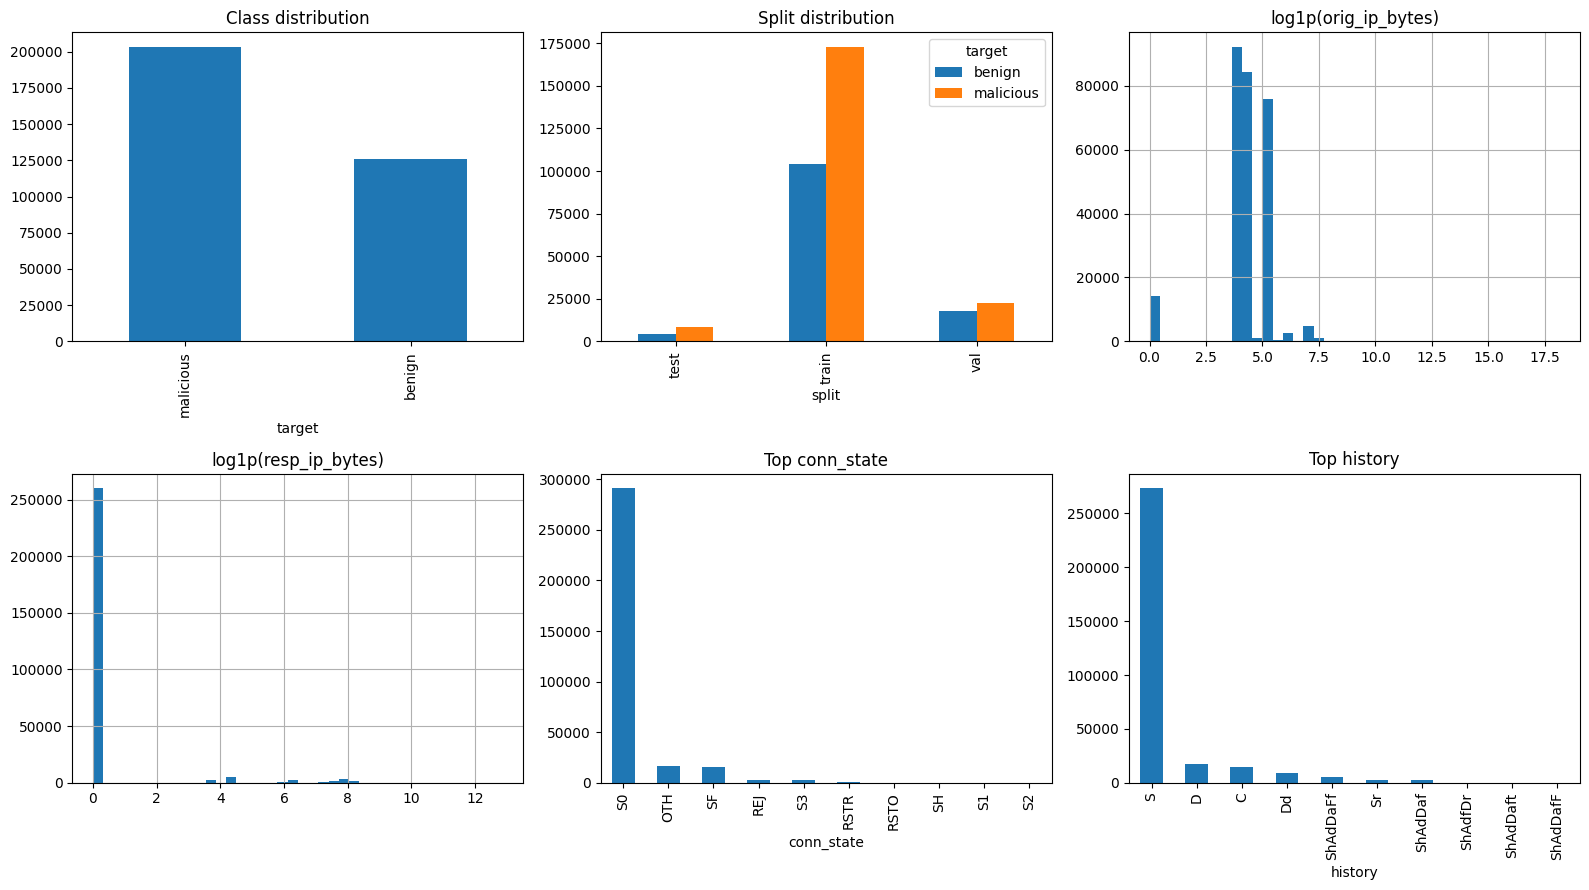

Missing percentage


,feature,missing_pct
0,service,96.44
1,orig_bytes,67.08
2,duration,67.08
3,resp_bytes,67.08
4,history,0.72
5,orig_pkts,0.00
6,orig_ip_bytes,0.00
7,resp_ip_bytes,0.00
8,resp_pkts,0.00
9,proto,0.00


Outlier percentage (IQR)


,feature,outlier_pct
0,duration,25.85
1,orig_bytes,18.01
2,resp_bytes,16.93
3,resp_ip_bytes,6.56
4,resp_pkts,6.56
5,orig_ip_bytes,2.89
6,orig_pkts,2.82


In [ ]:
analysis_num_cols = ["duration", "orig_bytes", "resp_bytes", "orig_pkts", "orig_ip_bytes", "resp_pkts", "resp_ip_bytes"]
analysis_cat_cols = ["proto", "service", "conn_state", "history"]

analysis_df = raw_df[analysis_num_cols + analysis_cat_cols + ["target", "capture"]].copy()
analysis_df = analysis_df.mask(analysis_df.isin(["-", "(empty)"]))

for col in analysis_num_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

missing_pct = (
    analysis_df[analysis_num_cols + analysis_cat_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename_axis("feature")
    .reset_index(name="missing_pct")
)

outlier_rows = []
for col in analysis_num_cols:
    s = analysis_df[col].dropna()

    if len(s) < 4:
        continue
    q1, q3 = s.quantile([0.25, 0.75])

    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_rows.append(
        {
            "feature": col,
            "outlier_pct": round(((s < lower) | (s > upper)).mean() * 100, 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False).reset_index(drop=True)

split_counts = pd.concat(
    [
        train_raw_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
).groupby(["split", "target"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

analysis_df["target"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Class distribution")
split_counts.plot(kind="bar", ax=axes[0, 1], title="Split distribution")

np.log1p(train_raw_df["orig_ip_bytes"].replace({"-": np.nan, "(empty)": np.nan}).astype(float)).dropna().hist(bins=40, ax=axes[0, 2])
axes[0, 2].set_title("log1p(orig_ip_bytes)")

np.log1p(train_raw_df["resp_ip_bytes"].replace({"-": np.nan, "(empty)": np.nan}).astype(float)).dropna().hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title("log1p(resp_ip_bytes)")

analysis_df["conn_state"].value_counts().head(10).plot(kind="bar", ax=axes[1, 1], title="Top conn_state")
analysis_df["history"].value_counts().head(10).plot(kind="bar", ax=axes[1, 2], title="Top history")

plt.tight_layout()
plt.show()

print("Missing percentage")
display(missing_pct)

print("Outlier percentage (IQR)")
display(outlier_summary)


In [ ]:
zeror_class = train_raw_df["target"].mode()[0]
zeror_pred = pd.Series(zeror_class, index=y_val.index)

zeror_summary = pd.DataFrame(
    [
        {
            "baseline": "ZeroR",
            "predicted_class": zeror_class,
            **metric_row(y_val, zeror_pred),
        }
    ]
)

print("ZeroR on validation")
display(zeror_summary)


ZeroR on validation


,baseline,predicted_class,accuracy,precision,recall,f1
0,ZeroR,malicious,0.556275,0.556275,1.0,0.71488


In [ ]:
lr_params = {
    "C": 1.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "max_iter": 1000,
}

lr = make_model(LogisticRegression(**lr_params, random_state=SEED))
lr.fit(X_train_df, y_train)

lr_train_pred = lr.predict(X_train_df)
lr_val_pred = lr.predict(X_val_df)
lr_summary = train_val_summary(lr_train_pred, lr_val_pred)

print("Logistic Regression")
print(lr_params)
display(lr_summary)


Logistic Regression
{'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1000}


,split,accuracy,precision,recall,f1
0,train,0.927358,0.988436,0.864834,0.922513
1,val,0.975000,0.972265,0.983102,0.977654


In [ ]:
svm_params = {
    "C": 1.0,
    "loss": "squared_hinge",
    "dual": False,
    "max_iter": 10000,
}

svm = make_model(LinearSVC(**svm_params, random_state=SEED))
svm.fit(X_train_df, y_train)

svm_train_pred = svm.predict(X_train_df)
svm_val_pred = svm.predict(X_val_df)
svm_summary = train_val_summary(svm_train_pred, svm_val_pred)

print("Linear SVM")
print(svm_params)
display(svm_summary)


Linear SVM
{'C': 1.0, 'loss': 'squared_hinge', 'dual': False, 'max_iter': 10000}


,split,accuracy,precision,recall,f1
0,train,0.927416,0.988577,0.864824,0.922569
1,val,0.975650,0.973390,0.983102,0.978222


In [ ]:
rf_params = {
    "n_estimators": 300,
    "max_depth": 2,
    "min_samples_split": 8000,
    "min_samples_leaf": 3000,
    "max_leaf_nodes": 6,
    "max_features": 0.3,
    "class_weight": "balanced_subsample",
    "max_samples": 0.25,
    "ccp_alpha": 0.01,
    "n_jobs": -1,
}

rf = make_model(RandomForestClassifier(**rf_params, random_state=SEED))
rf.fit(X_train_df, y_train)

rf_train_pred = rf.predict(X_train_df)
rf_val_pred = rf.predict(X_val_df)
rf_summary = train_val_summary(rf_train_pred, rf_val_pred)

print("Random Forest")
print(rf_params)
display(rf_summary)


Random Forest
{'n_estimators': 300, 'max_depth': 2, 'min_samples_split': 8000, 'min_samples_leaf': 3000, 'max_leaf_nodes': 6, 'max_features': 0.3, 'class_weight': 'balanced_subsample', 'max_samples': 0.25, 'ccp_alpha': 0.01, 'n_jobs': -1}


,split,accuracy,precision,recall,f1
0,train,0.927291,0.936827,0.916375,0.926488
1,val,0.936450,0.901913,0.993843,0.945649


In [ ]:
val_comparison = pd.concat(
    [
        zeror_summary.assign(model="ZeroR", split="val").drop(columns=["baseline", "predicted_class"], errors="ignore"),
        lr_summary.assign(model="LogisticRegression"),
        svm_summary.assign(model="LinearSVM"),
        rf_summary.assign(model="RandomForest"),
    ],
    ignore_index=True,
)

val_comparison = (
    val_comparison[val_comparison["split"] == "val"]
    [["model", "accuracy", "precision", "recall", "f1"]]
    .sort_values(["f1", "accuracy"], ascending=[False, False])
    .reset_index(drop=True)
)

best_model = val_comparison.loc[0, "model"]

print("Validation comparison")
display(val_comparison)
print("Best model:", best_model)


Validation comparison


,model,accuracy,precision,recall,f1
0,LinearSVM,0.975650,0.973390,0.983102,0.978222
1,LogisticRegression,0.975000,0.972265,0.983102,0.977654
2,RandomForest,0.936450,0.901913,0.993843,0.945649
3,ZeroR,0.556275,0.556275,1.000000,0.714880


Best model: LinearSVM


In [ ]:
fitted_models = {
    "LogisticRegression": lr,
    "LinearSVM": svm,
    "RandomForest": rf,
}


def positive_score(model_name):
    if model_name == "ZeroR":
        return pd.Series(float(zeror_class == "malicious"), index=y_test.index)

    model = fitted_models[model_name]
    estimator = model.named_steps["model"]

    if hasattr(estimator, "predict_proba"):
        malicious_idx = list(estimator.classes_).index("malicious")
        return model.predict_proba(X_test_df)[:, malicious_idx]

    return model.decision_function(X_test_df)


test_predictions = {
    "ZeroR": pd.Series(zeror_class, index=y_test.index),
    **{model_name: model.predict(X_test_df) for model_name, model in fitted_models.items()},
}

test_scores = {
    model_name: positive_score(model_name)
    for model_name in test_predictions
}

y_test_bin = y_test.eq("malicious").astype(int)

test_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            **metric_row(y_test, pred),
            "roc_auc": roc_auc_score(y_test_bin, test_scores[model_name]),
        }
        for model_name, pred in test_predictions.items()
    ]
)

test_summary = (
    test_summary
    .set_index("model")
    .loc[val_comparison["model"]]
    .reset_index()
)

test_pred = test_predictions[best_model]
test_score = test_scores[best_model]
final_model = fitted_models.get(best_model)

print("Final test")
display(test_summary)


Final test


,model,accuracy,precision,recall,f1,roc_auc
0,LinearSVM,0.966616,0.951841,1.0,0.975326,0.996226
1,LogisticRegression,0.965171,0.949861,1.0,0.974286,0.904753
2,RandomForest,0.881791,0.848066,1.0,0.917788,0.972401
3,ZeroR,0.659819,0.659819,1.0,0.795049,0.500000


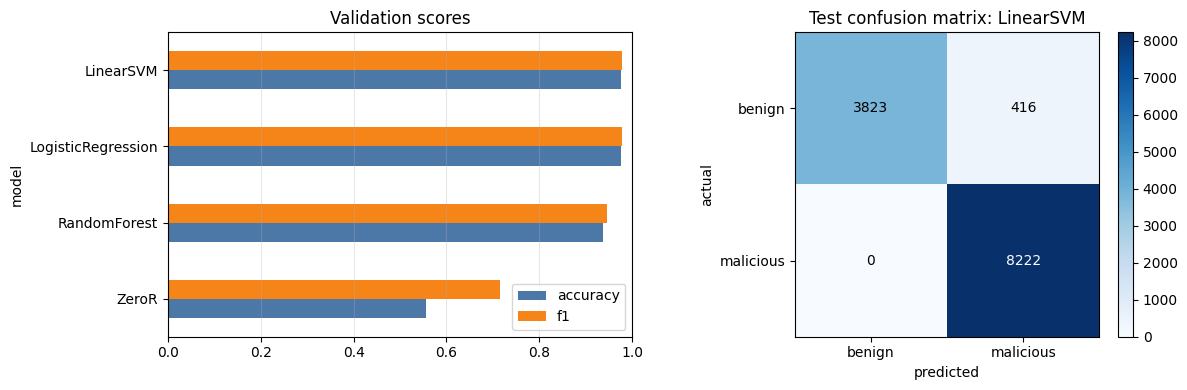

,pred_benign,pred_malicious
true_benign,3823,416
true_malicious,0,8222


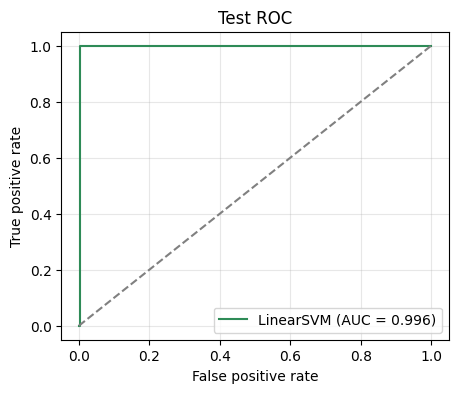

Discussion draft
- Best validation model: LinearSVM.
- Validation accuracy = 0.976; validation F1 = 0.978.
- Test accuracy = 0.967; test F1 = 0.975.
- Test precision = 0.952; test recall = 1.000.
- Test ROC-AUC = 0.996.


In [ ]:
labels = ["benign", "malicious"]

cm = pd.DataFrame(
    confusion_matrix(y_test, test_pred, labels=labels),
    index=[f"true_{label}" for label in labels],
    columns=[f"pred_{label}" for label in labels],
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(
    val_comparison.sort_values("f1")
    .set_index("model")[["accuracy", "f1"]]
    .plot(kind="barh", ax=axes[0], color=["#4C78A8", "#F58518"])
)


axes[0].set_title("Validation scores")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title(f"Test confusion matrix: {best_model}")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_yticks(range(len(labels)))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("actual")

for i in range(len(labels)):
    for j in range(len(labels)):
        value = cm.iloc[i, j]
        color = "white" if value > cm.to_numpy().max() / 2 else "black"
        axes[1].text(j, i, value, ha="center", va="center", color=color)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
display(cm)

fpr, tpr, _ = roc_curve(y_test_bin, test_score)
roc_auc = test_summary.set_index("model").loc[best_model, "roc_auc"]

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_model} (AUC = {roc_auc:.3f})", color="#2E8B57")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Test ROC")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

val_row = val_comparison.set_index("model").loc[best_model]
test_row = test_summary.set_index("model").loc[best_model]

discussion = [
    f"Best validation model: {best_model}.",
    f"Validation accuracy = {val_row['accuracy']:.3f}; validation F1 = {val_row['f1']:.3f}.",
    f"Test accuracy = {test_row['accuracy']:.3f}; test F1 = {test_row['f1']:.3f}.",
    f"Test precision = {test_row['precision']:.3f}; test recall = {test_row['recall']:.3f}.",
    f"Test ROC-AUC = {test_row['roc_auc']:.3f}.",
]

print("Discussion draft")
for line in discussion:
    print(f"- {line}")


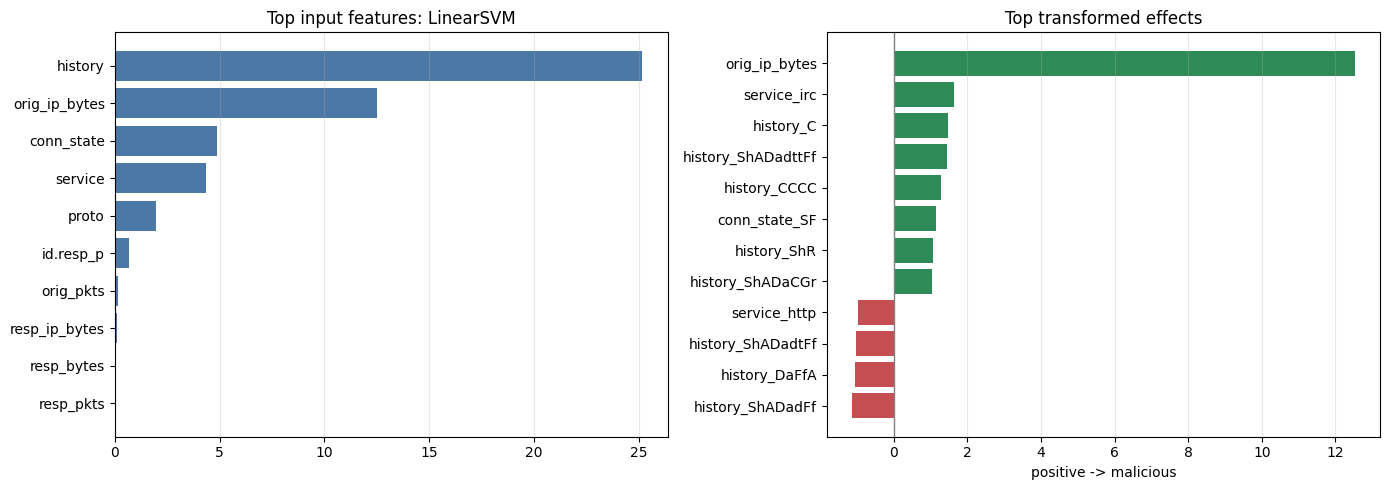

Feature contribution by input feature


,input_feature,importance
0,history,25.138241
1,orig_ip_bytes,12.528733
2,conn_state,4.855729
3,service,4.339653
4,proto,1.953417
5,id.resp_p,0.667636
6,orig_pkts,0.149892
7,resp_ip_bytes,0.108433
8,resp_bytes,0.064825
9,resp_pkts,0.059489


Top transformed features


,feature,importance,weight,direction
0,orig_ip_bytes,12.528733,12.528733,malicious
1,service_irc,1.639069,1.639069,malicious
2,history_C,1.460552,1.460552,malicious
3,history_ShADadttFf,1.439157,1.439157,malicious
4,history_CCCC,1.290543,1.290543,malicious
5,history_ShADadFf,1.142018,-1.142018,benign
6,conn_state_SF,1.133280,1.133280,malicious
7,history_ShR,1.062613,1.062613,malicious
8,history_DaFfA,1.050539,-1.050539,benign
9,history_ShADadtFf,1.043110,-1.043110,benign


In [ ]:
selected_pipe = fitted_models.get(best_model)
selected_model = selected_pipe.named_steps["model"] if selected_pipe is not None else None
preprocessor = selected_pipe.named_steps["preprocessor"] if selected_pipe is not None else None

if selected_model is None:
    print("Feature contribution is not available for ZeroR.")
else:
    feature_names = (
        pd.Index(preprocessor.get_feature_names_out())
        .str.replace("num__", "", regex=False)
        .str.replace("cat__", "", regex=False)
    )

    is_linear = hasattr(selected_model, "coef_")

    if is_linear:
        feature_detail = pd.DataFrame(
            {
                "feature": feature_names,
                "weight": selected_model.coef_[0],
            }
        )
        feature_detail["importance"] = feature_detail["weight"].abs()
        feature_detail["direction"] = np.where(
            feature_detail["weight"] >= 0,
            selected_model.classes_[1],
            selected_model.classes_[0],
        )
    else:
        feature_detail = pd.DataFrame(
            {
                "feature": feature_names,
                "importance": selected_model.feature_importances_,
            }
        )

    def input_feature(name):
        return next((col for col in cat_cols if name.startswith(f"{col}_")), name)

    feature_detail = feature_detail.sort_values("importance", ascending=False).reset_index(drop=True)
    feature_groups = (
        feature_detail.assign(input_feature=feature_detail["feature"].map(input_feature))
        .groupby("input_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    top_groups = feature_groups.head(10).sort_values("importance")
    axes[0].barh(top_groups["input_feature"], top_groups["importance"], color="#4C78A8")
    axes[0].set_title(f"Top input features: {best_model}")
    axes[0].grid(axis="x", alpha=0.3)

    if is_linear:
        top_effects = feature_detail.head(12).sort_values("weight")
        colors = np.where(top_effects["weight"] >= 0, "#2E8B57", "#C44E52")
        axes[1].barh(top_effects["feature"], top_effects["weight"], color=colors)
        axes[1].axvline(0, color="gray", linewidth=1)
        axes[1].set_xlabel(f"positive -> {selected_model.classes_[1]}")
        axes[1].set_title("Top transformed effects")
    else:
        top_effects = feature_detail.head(12).sort_values("importance")
        axes[1].barh(top_effects["feature"], top_effects["importance"], color="#F58518")
        axes[1].set_title("Top transformed features")

    axes[1].grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Feature contribution by input feature")
    display(feature_groups.head(10))

    print("Top transformed features")
    display(feature_detail[[c for c in ["feature", "importance", "weight", "direction"] if c in feature_detail.columns]].head(15))
